In [136]:
import numpy as np
import os, sys
import importlib.util

import mplhep as hep
import matplotlib.pyplot as plt
# Use CMS style from mplhep for plotting
plt.style.use(hep.style.CMS)

# Load the cross section modules
spec = importlib.util.spec_from_file_location(
    "fidXS_PTH_ggH",
    "/work/niharrin/devel/RCR_Matrix/fidXS/fidXS_PTH_ggH.py"
)
ggh_xs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ggh_xs)

spec = importlib.util.spec_from_file_location(
    "fidXS_PTH_VBFH",
    "/work/niharrin/devel/RCR_Matrix/fidXS/fidXS_PTH_VBFH.py"
)
vbf_xs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(vbf_xs)

spec = importlib.util.spec_from_file_location(
    "fidXS_PTH_VH",
    "/work/niharrin/devel/RCR_Matrix/fidXS/fidXS_PTH_VH.py"
)
vh_xs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(vh_xs)

spec = importlib.util.spec_from_file_location(
    "fidXS_PTH_ttH",
    "/work/niharrin/devel/RCR_Matrix/fidXS/fidXS_PTH_ttH.py"
)
tth_xs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tth_xs)

In [137]:
def format_bin_edge(edge: float) -> str:
    """Converts a numerical bin edge to the datacard string format."""
    return str(float(edge)).replace('.', 'p')

def generate_nuisance_lines(
    datacard_path: str, 
    bins: list, 
    nuisances_data: dict, 
    output_path: str
):
    """
    Parses a combine datacard and appends process-specific 
    theory uncertainties based on nested dictionary mapping.
    """
    
    # 1. Build the bin signature mapping (e.g., '_5p0_10p0_')
    bin_map = {}
    for i in range(len(bins) - 1):
        low_str = format_bin_edge(bins[i])
        high_str = format_bin_edge(bins[i+1])
        signature = f"_{low_str}_{high_str}_"
        bin_map[signature] = i

    # 2. Read the existing datacard
    with open(datacard_path, 'r') as f:
        lines = f.readlines()

    bin_tokens = []
    process_tokens = []

    # 3. Locate the 'bin' and 'process' lines
    for i, line in enumerate(lines):
        if line.startswith('bin'):
            for j in range(1, 3):
                if i + j < len(lines) and lines[i + j].startswith('process'):
                    b_toks = line.strip().split()
                    p_toks = lines[i + j].strip().split()
                    
                    if len(b_toks) == len(p_toks) and not p_toks[1].lstrip('-').isdigit():
                        bin_tokens = b_toks
                        process_tokens = p_toks
                        break
            if bin_tokens:
                break

    if not bin_tokens or not process_tokens:
        raise ValueError("Could not find matching 'bin' and 'process' lines.")

    # 4. Dynamically find all unique nuisance names across all processes
    unique_nuisance_names = []
    for proc_dict in nuisances_data.values():
        for nu_name in proc_dict.keys():
            if nu_name not in unique_nuisance_names:
                unique_nuisance_names.append(nu_name)

    # 5. Generate the new nuisance lines row by row
    new_nuisance_lines = []
    
    for nuisance_name in unique_nuisance_names:
        line_parts = [f"{nuisance_name:<30}", "lnN"]
        
        # Iterate through the columns
        for b_col, p_col in zip(bin_tokens[1:], process_tokens[1:]):
            if p_col == 'bkg_mass':
                line_parts.append("-")
                continue
            
            # Extract the base process (e.g., 'ggh' from 'ggh_PTH_0p0_5p0...')
            base_proc = p_col.split('_')[0]
            
            # Find the bin index by looking for the signature in the BIN string (b_col)
            found_idx = -1
            for signature, idx in bin_map.items():
                if signature in b_col:
                    found_idx = idx
                    break
            
            # If the process exists in our dict, AND this specific nuisance applies 
            # to this process, AND we found the bin index -> add the values.
            if (base_proc in nuisances_data and 
                nuisance_name in nuisances_data[base_proc] and 
                found_idx != -1):
                
                up_arr, dn_arr = nuisances_data[base_proc][nuisance_name]
                up_val = up_arr[found_idx]
                dn_val = dn_arr[found_idx]
                line_parts.append(f"{up_val:.3f}/{dn_val:.3f}")
            else:
                # Default for backgrounds, unmatched signals, or cross-process mismatches
                line_parts.append("-")
        
        new_nuisance_lines.append("   ".join(line_parts) + "\n")

    # 6. Write to the new datacard
    with open(output_path, 'w') as f:
        f.writelines(lines)
        if not lines[-1].endswith('\n'):
            f.write('\n')
        f.write("--------------------------------------------------\n")
        f.writelines(new_nuisance_lines)
        
    print(f"Successfully added {len(unique_nuisance_names)} nuisance lines to {output_path}")

In [138]:
# fidXS
fidXS = {}

# List of variables to import
vars = ['fidXS', 'fidXS_scale_up', 'fidXS_scale_dn', 'fidXS_pdf_up', 'fidXS_pdf_dn', 'fidXS_alpha_up', 'fidXS_alpha_dn', 'Boundaries']

# Dynamically import the required module for ggH cross-section
bins = ggh_xs.Boundaries
bins_plot = np.array(bins)

# if "overflow" in current_config.keys(): bins_plot[-1] = 500
bins_plot[-1] = 10000 # We look at PTH
bins[-1] = 10000

# Calculate bin centers and widths
bins_c = (bins_plot[1:]+bins_plot[:-1])*0.5
bin_w = np.array([bins_plot[k+1]-bins_plot[k] for k in range(len(bins)-1)])
fidXS['ggh'] = np.array(ggh_xs.fidXS)
ggh_acc_norm = fidXS['ggh'] / bin_w

# Dynamically import the required module for xH cross-section
# xh_acc = __import__(current_config['xh_acc'], globals(), locals(), vars)
# xh_acc_norm = np.array(xh_acc.Acc) / bin_w

# Dynamically import the required module for VBF, VH, and ttH cross-section
fidXS['vbf'] = np.array(vbf_xs.fidXS)
vbf_acc_norm = fidXS['vbf'] / bin_w

fidXS['vh'] = np.array(vh_xs.fidXS)
vh_acc_norm = fidXS['vh'] / bin_w

fidXS['tth'] = np.array(tth_xs.fidXS)
tth_acc_norm = fidXS['tth'] / bin_w

In [139]:
# Theoretical uncertainty
sources_up = ["fidXS_scale_up", "fidXS_pdf_up", "fidXS_alpha_up"]

## [[fidXS_scale_up unc per bin], [fidXS_pdf_up unc per bin], [fidXS_alpha_up unc per bin]]
ggh_up = [(abs(np.array(getattr(ggh_xs, source)) - np.array(ggh_xs.fidXS))) for source in sources_up]
vbf_up = [(abs(np.array(getattr(vbf_xs, source)) - np.array(vbf_xs.fidXS))) for source in sources_up]
vh_up = [(abs(np.array(getattr(vh_xs, source)) - np.array(vh_xs.fidXS))) for source in sources_up]
tth_up = [(abs(np.array(getattr(tth_xs, source)) - np.array(tth_xs.fidXS))) for source in sources_up]

sources_dn = ["fidXS_scale_dn", "fidXS_pdf_dn", "fidXS_alpha_dn"]

ggh_dn = [(abs(np.array(getattr(ggh_xs, source)) - np.array(ggh_xs.fidXS))) for source in sources_dn]
vbf_dn = [(abs(np.array(getattr(vbf_xs, source)) - np.array(vbf_xs.fidXS))) for source in sources_dn]
vh_dn = [(abs(np.array(getattr(vh_xs, source)) - np.array(vh_xs.fidXS))) for source in sources_dn]
tth_dn = [(abs(np.array(getattr(tth_xs, source)) - np.array(tth_xs.fidXS))) for source in sources_dn]

ggh_norm_up = ggh_up / fidXS['ggh']
vbf_norm_up = vbf_up / fidXS['vbf']
vh_norm_up = vh_up / fidXS['vh']
tth_norm_up = tth_up / fidXS['tth']

ggh_norm_dn = ggh_dn / fidXS['ggh']
vbf_norm_dn = vbf_dn / fidXS['vbf']
vh_norm_dn = vh_dn / fidXS['vh']
tth_norm_dn = tth_dn / fidXS['tth']

In [140]:
dc_ggh_up = (1 + ggh_norm_up)
dc_ggh_dn = (1 - ggh_norm_dn)

dc_vbf_up = (1 + vbf_norm_up)
dc_vbf_dn = (1 - vbf_norm_dn)

dc_vh_up = (1 + vh_norm_up)
dc_vh_dn = (1 - vh_norm_dn)

dc_tth_up = (1 + tth_norm_up)
dc_tth_dn = (1 - tth_norm_dn)


In [141]:
CMS_hgg_theory_scale_ggh_up = dc_ggh_up[0]
CMS_hgg_theory_scale_ggh_dn = dc_ggh_dn[0]

CMS_hgg_theory_pdfWeight_ggh_up = dc_ggh_up[1]
CMS_hgg_theory_pdfWeight_ggh_dn = dc_ggh_dn[1]

CMS_hgg_theory_AlphaS_ggh_up = dc_ggh_up[2]
CMS_hgg_theory_AlphaS_ggh_dn = dc_ggh_dn[2]

CMS_hgg_theory_scale_vbf_up = dc_vbf_up[0]
CMS_hgg_theory_scale_vbf_dn = dc_vbf_dn[0]

CMS_hgg_theory_pdfWeight_vbf_up = dc_vbf_up[1]
CMS_hgg_theory_pdfWeight_vbf_dn = dc_vbf_dn[1]

CMS_hgg_theory_AlphaS_vbf_up = dc_vbf_up[2]
CMS_hgg_theory_AlphaS_vbf_dn = dc_vbf_dn[2]

CMS_hgg_theory_scale_vh_up = dc_vh_up[0]
CMS_hgg_theory_scale_vh_dn = dc_vh_dn[0]

CMS_hgg_theory_pdfWeight_vh_up = dc_vh_up[1]
CMS_hgg_theory_pdfWeight_vh_dn = dc_vh_dn[1]

CMS_hgg_theory_AlphaS_vh_up = dc_vh_up[2]
CMS_hgg_theory_AlphaS_vh_dn = dc_vh_dn[2]

CMS_hgg_theory_scale_tth_up = dc_tth_up[0]
CMS_hgg_theory_scale_tth_dn = dc_tth_dn[0]

CMS_hgg_theory_pdfWeight_tth_up = dc_tth_up[1]
CMS_hgg_theory_pdfWeight_tth_dn = dc_tth_dn[1]

CMS_hgg_theory_AlphaS_tth_up = dc_tth_up[2]
CMS_hgg_theory_AlphaS_tth_dn = dc_tth_dn[2]

In [142]:
# Map the root nuisance name to the (up, down) tuple
nuisances = {
    "ggh": {
        "CMS_hgg_THU_scale": (CMS_hgg_theory_scale_ggh_up, CMS_hgg_theory_scale_ggh_dn),
        "CMS_hgg_THU_pdfWeight": (CMS_hgg_theory_pdfWeight_ggh_up, CMS_hgg_theory_pdfWeight_ggh_dn),
        "CMS_hgg_THU_AlphaS": (CMS_hgg_theory_AlphaS_ggh_up, CMS_hgg_theory_AlphaS_ggh_dn),
    },
    "vbf": {
        "CMS_hgg_THU_scale": (CMS_hgg_theory_scale_vbf_up, CMS_hgg_theory_scale_vbf_dn),
        "CMS_hgg_THU_pdfWeight": (CMS_hgg_theory_pdfWeight_vbf_up, CMS_hgg_theory_pdfWeight_vbf_dn),
        "CMS_hgg_THU_AlphaS": (CMS_hgg_theory_AlphaS_vbf_up, CMS_hgg_theory_AlphaS_vbf_dn),
    }, 
    "vh": {
        "CMS_hgg_THU_scale": (CMS_hgg_theory_scale_vh_up, CMS_hgg_theory_scale_vh_dn),
        "CMS_hgg_THU_pdfWeight": (CMS_hgg_theory_pdfWeight_vh_up, CMS_hgg_theory_pdfWeight_vh_dn),
        "CMS_hgg_THU_AlphaS": (CMS_hgg_theory_AlphaS_vh_up, CMS_hgg_theory_AlphaS_vh_dn),
    },
    "tth": {
        "CMS_hgg_THU_scale": (CMS_hgg_theory_scale_tth_up, CMS_hgg_theory_scale_tth_dn),
        "CMS_hgg_THU_pdfWeight": (CMS_hgg_theory_pdfWeight_tth_up, CMS_hgg_theory_pdfWeight_tth_dn),
        "CMS_hgg_THU_AlphaS": (CMS_hgg_theory_AlphaS_tth_up, CMS_hgg_theory_AlphaS_tth_dn),
    }
}

# Run the generator
generate_nuisance_lines(
    datacard_path='/work/niharrin/devel/RCR_Matrix/theoretical_uncertainties/datacards/Datacard_PTH_2022.txt', 
    bins=bins, 
    nuisances_data=nuisances, 
    output_path='/work/niharrin/devel/RCR_Matrix/theoretical_uncertainties/datacards/datacard_with_nuisances_2.txt'
)

Successfully added 3 nuisance lines to /work/niharrin/devel/RCR_Matrix/theoretical_uncertainties/datacards/datacard_with_nuisances_2.txt


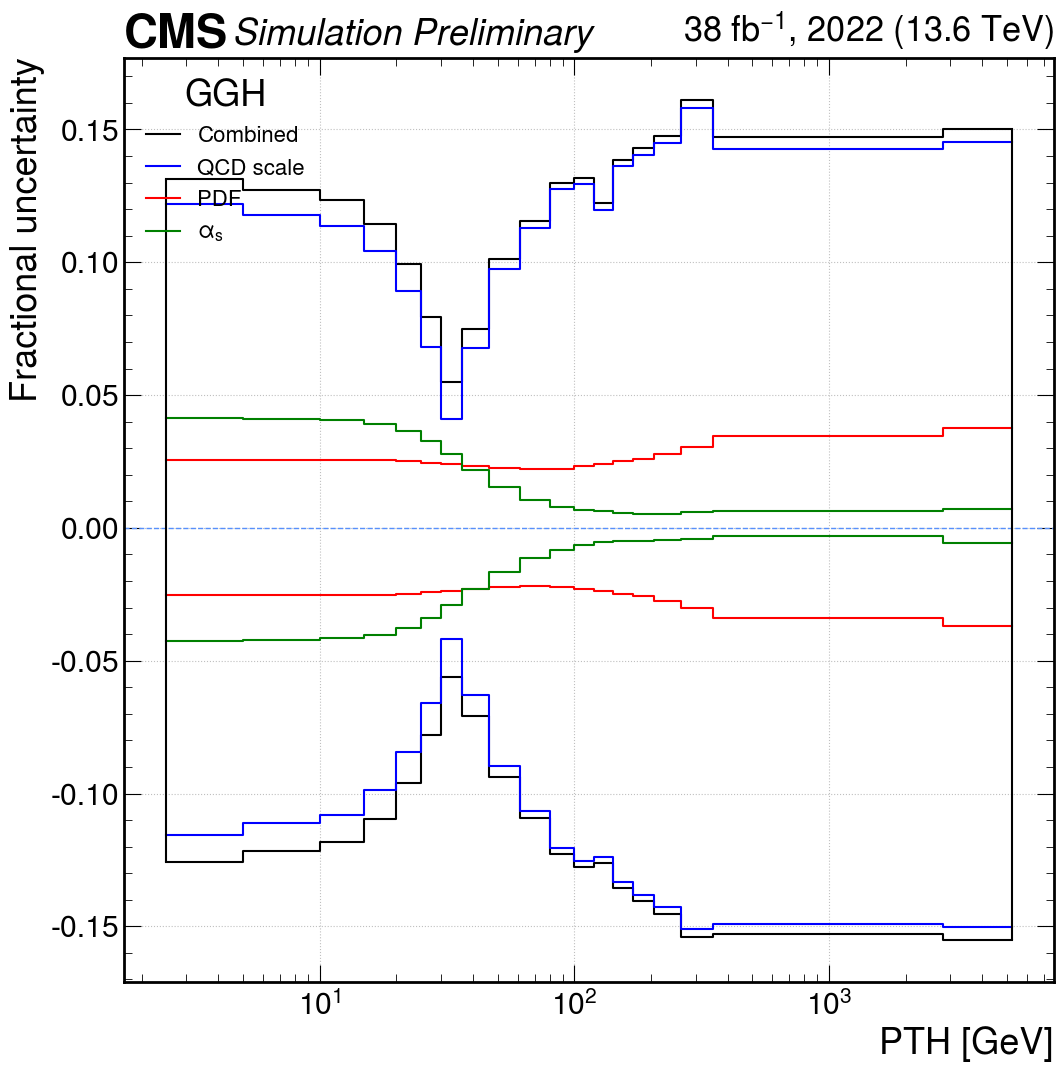

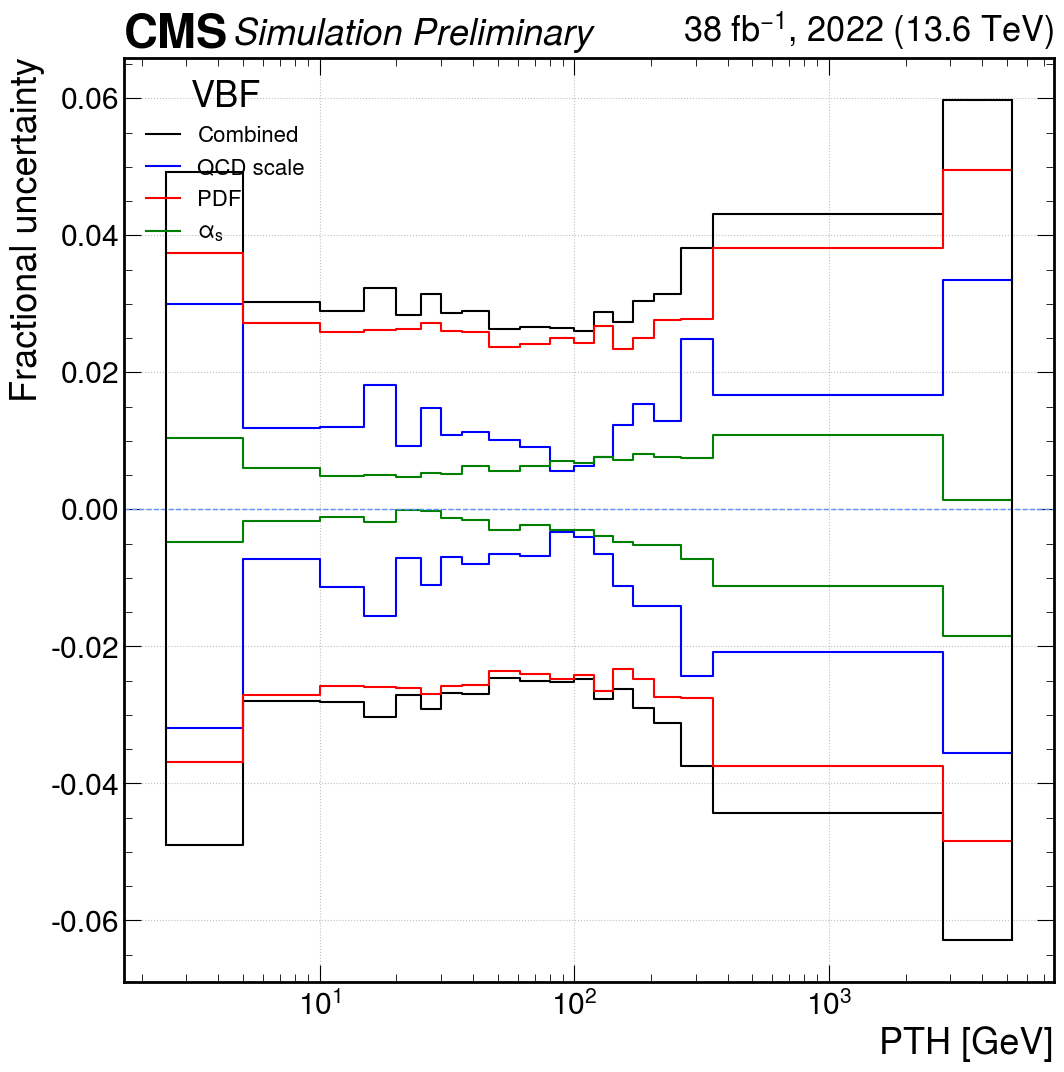

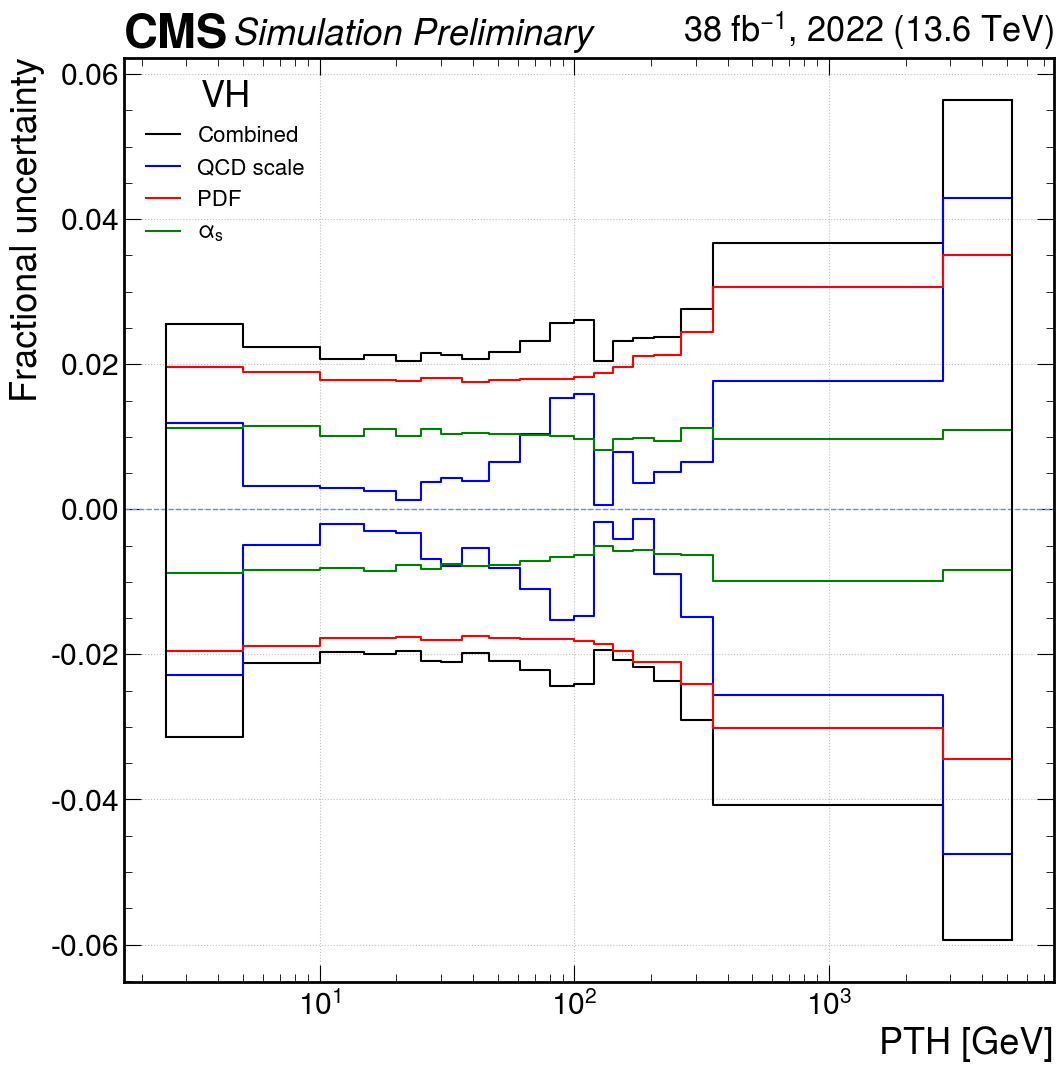

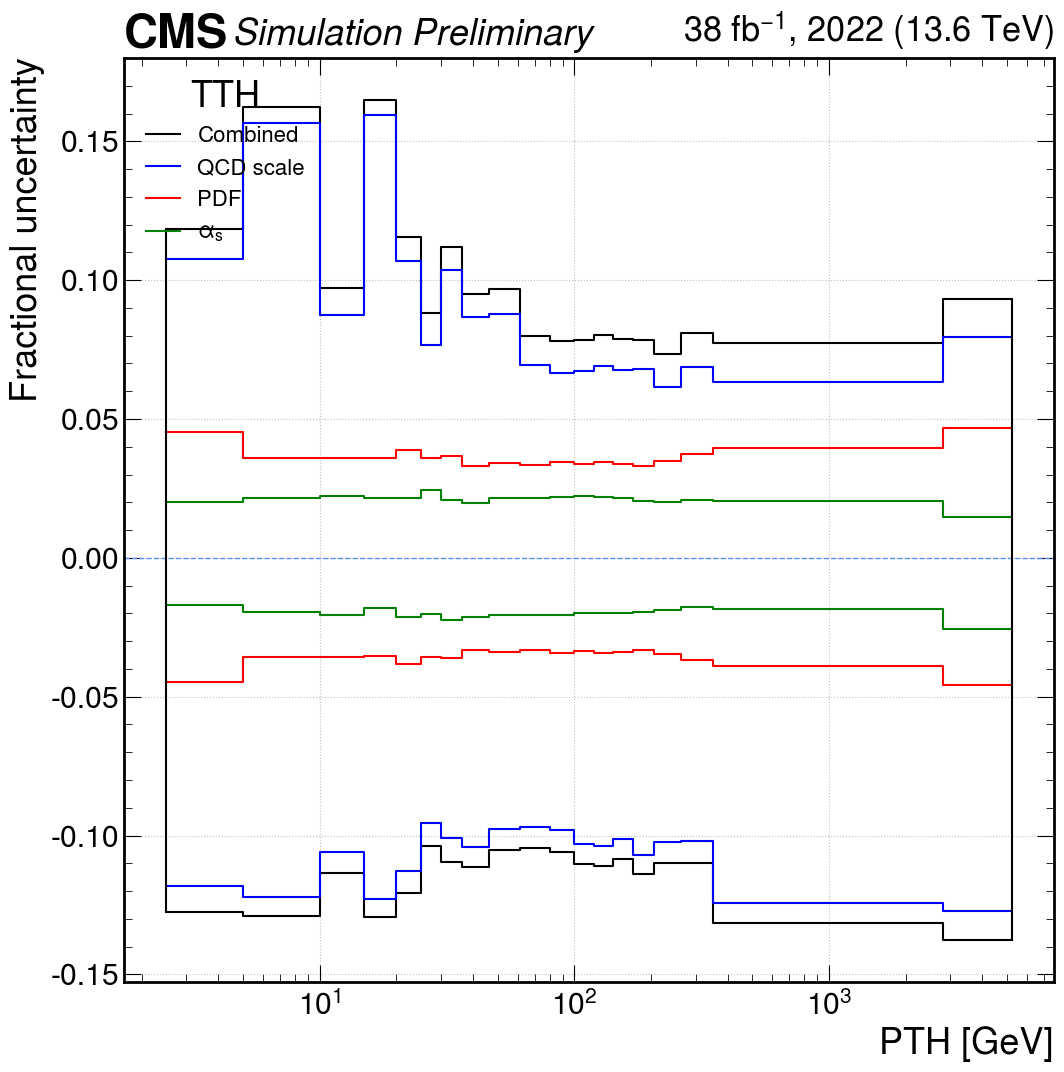

In [161]:
# Plot up nuisances
proc_list = list(nuisances.keys())
for proc in proc_list:
    scale_up_variation   = nuisances[proc]['CMS_hgg_THU_scale'][0] - 1
    pdf_up_variation     = nuisances[proc]['CMS_hgg_THU_pdfWeight'][0] - 1
    alphas_up_variation  = nuisances[proc]['CMS_hgg_THU_AlphaS'][0] - 1

    scale_dn_variation   = 1 - nuisances[proc]['CMS_hgg_THU_scale'][1]
    pdf_dn_variation     = 1 - nuisances[proc]['CMS_hgg_THU_pdfWeight'][1]
    alphas_dn_variation  = 1 - nuisances[proc]['CMS_hgg_THU_AlphaS'][1]

    combined_up_variation = np.sqrt(
        np.sum(np.square([scale_up_variation,
                          pdf_up_variation,
                          alphas_up_variation]), axis=0)
    )

    combined_dn_variation = np.sqrt(
        np.sum(np.square([scale_dn_variation,
                          pdf_dn_variation,
                          alphas_dn_variation]), axis=0)
    )

    plt.figure(figsize=(12, 12))
    hep.cms.label(
        loc=0, data=False, label="Preliminary",
        lumi="38", year="2022", com="13.6"
    )

    # up
    plt.step(bins_c, combined_up_variation, where='mid',
             color='black', label='Combined')
    plt.step(bins_c, scale_up_variation, where='mid',
             color='blue', label='QCD scale')
    plt.step(bins_c, pdf_up_variation, where='mid',
             color='red', label='PDF')
    plt.step(bins_c, alphas_up_variation, where='mid',
             color='green', label=r'$\alpha_s$')

    # down (mirror below zero)
    plt.step(bins_c, -combined_dn_variation, where='mid',
             color='black')
    plt.step(bins_c, -scale_dn_variation, where='mid',
             color='blue')
    plt.step(bins_c, -pdf_dn_variation, where='mid',
             color='red')
    plt.step(bins_c, -alphas_dn_variation, where='mid',
             color='green')

    # zero line
    plt.axhline(0, linestyle='--', linewidth=1)

    # vertical edges
    plt.vlines(bins_c[0], 0, combined_up_variation[0], color='black')
    plt.vlines(bins_c[-1], 0, combined_up_variation[-1], color='black')
    plt.vlines(bins_c[0], 0, -combined_dn_variation[0], color='black')
    plt.vlines(bins_c[-1], 0, -combined_dn_variation[-1], color='black')

    plt.legend(fontsize=16, loc='upper left', title=proc.upper())
    plt.grid()
    plt.semilogx()
    plt.xlabel("PTH [GeV]")
    plt.ylabel("Fractional uncertainty")
    plt.savefig(f"/work/niharrin/devel/RCR_Matrix/theoretical_uncertainties/Plots/{proc}.png")
    plt.savefig(f"/work/niharrin/devel/RCR_Matrix/theoretical_uncertainties/Plots/{proc}.pdf")
